In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
#Part a
#Read the dataset
biomass = pd.read_csv('biomass.csv', encoding='latin1')

#To see what the first 5 rows actually contain
print(biomass[['SITE', 'YEAR', 'TREAT']].head(10))

   SITE  YEAR  TREAT
0     1  2003      1
1     1  2003      1
2     1  2003      1
3     1  2003      1
4     1  2003      1
5     1  2003      1
6     1  2003      1
7     1  2003      1
8     1  2003      1
9     1  2003      1


In [3]:
#Filtering the dataset
target_sites = [13, 14, 23, 25, 33, 52]

#Identify the first year of experimental data dynamically
first_year = biomass['YEAR'].min()

#To find the earliest year for each site individually
site_start_years = biomass.groupby('SITE')['YEAR'].min().reset_index()

#Merge this back to the main data so we know which rows are "Year 1" for each site
biomass_with_start = pd.merge(biomass, site_start_years, on='SITE', suffixes=('', '_START'))

#Filter for the target sites, their specific starting year, and treatment 1
biomass_filtered = biomass_with_start[
    (biomass_with_start['SITE'].isin(target_sites)) & 
    (biomass_with_start['YEAR'] == biomass_with_start['YEAR_START']) & 
    (biomass_with_start['TREAT'] == 1)
].copy()

#Summing the individual harvest yields (HARV_YIELD) for each unique plot
plot_yield = biomass_filtered.groupby(['SITE', 'PLOT'])['HARV_YIELD'].sum().reset_index()

#Calculating the mean across all plots for each site
site_avg_yield = plot_yield.groupby('SITE')['HARV_YIELD'].mean().reset_index()

#Renaming the column
site_avg_yield = site_avg_yield.rename(columns={'HARV_YIELD': 'AVG_ANNUAL_YIELD'})

#Final processed biomass data
print("Part (a): Average Annual Yield per Site")
print(site_avg_yield)

Part (a): Average Annual Yield per Site
   SITE  AVG_ANNUAL_YIELD
0    13          5.122750
1    14          2.067733
2    23          9.945782
3    25          9.633765
4    33          8.556006
5    52          7.969000


In [4]:
#Part (b)
#Read the dataset
climate = pd.read_csv('climate.csv', encoding='latin1')

#Filter the dataset to only sites 13, 14, 23, 25, 33 and 52
target_sites = [13, 14, 23, 25, 33, 52]
climate_filtered = climate[climate['SITE'].isin(target_sites)].copy()

#Data cleaning: Convert AIR_MEAN to numbers, forcing errors to 'NaN'
climate_filtered['AIR_MEAN'] = pd.to_numeric(climate_filtered['AIR_MEAN'], errors='coerce')

#Create a new dataset that provides the average ‘air mean’ for each site and each year
site_year_temp = climate_filtered.groupby(['SITE', 'YEAR'])['AIR_MEAN'].mean().reset_index()

#Renaming the column
site_year_temp = site_year_temp.rename(columns={'AIR_MEAN': 'AVG_AIR_TEMP'})

print("Part (b): Average Temperature per Site and Year")
print(site_year_temp.head(10)) #First 10 rows to verify the structure

Part (b): Average Temperature per Site and Year
   SITE  YEAR  AVG_AIR_TEMP
0    13  2002      7.460697
1    13  2003      5.818219
2    13  2004      5.328415
3    13  2005      4.783014
4    14  2003      7.451598
5    14  2004      5.328415
6    14  2005      4.783014
7    14  2006      5.242603
8    23  2002      5.144681
9    23  2003      4.249315


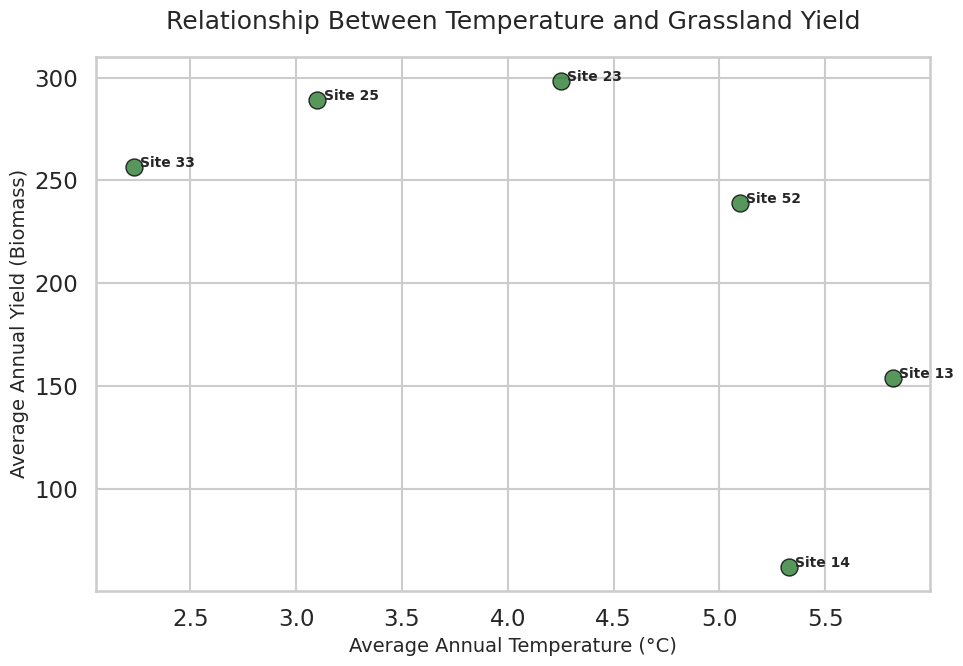

   SITE  YEAR  AVG_ANNUAL_YIELD  AVG_AIR_TEMP
0    13  2003        153.682500      5.818219
1    14  2004         62.032000      5.328415
2    23  2003        298.373447      4.249315
3    25  2004        289.012956      3.100180
4    33  2004        256.680179      2.231967
5    52  2005        239.069987      5.095342


In [5]:
#Part (c)

#Merging the datasets
biomass_for_merge = biomass_filtered.groupby(['SITE', 'YEAR'])['HARV_YIELD'].sum().reset_index()

#Average across plots for that specific year
site_yield_final = biomass_for_merge.groupby(['SITE', 'YEAR'])['HARV_YIELD'].mean().reset_index()
site_yield_final = site_yield_final.rename(columns={'HARV_YIELD': 'AVG_ANNUAL_YIELD'})

#Matching by SITE and YEAR
final_df = pd.merge(site_yield_final, site_year_temp, on=['SITE', 'YEAR'], how='inner')

#Creating a scatter plot
plt.figure(figsize=(10, 7))
sns.set_context("talk") #Makes labels larger and easier to read
sns.set_style("whitegrid")

plot = sns.scatterplot(
    data=final_df, 
    x='AVG_AIR_TEMP', 
    y='AVG_ANNUAL_YIELD', 
    s=150,                # Large, visible points
    color='#2e7d32',      # A nice "Grassland" green
    edgecolor='black', 
    alpha=0.8
)

#Labeling the points with their Site IDs
for i in range(final_df.shape[0]):
    plt.text(
        final_df.AVG_AIR_TEMP[i] + 0.03, 
        final_df.AVG_ANNUAL_YIELD[i] + 0.03, 
        f"Site {int(final_df.SITE[i])}", 
        fontsize=10, 
        weight='bold'
    )

#Adding titles and Labels
plt.title('Relationship Between Temperature and Grassland Yield', fontsize=18, pad=20)
plt.xlabel('Average Annual Temperature (°C)', fontsize=14)
plt.ylabel('Average Annual Yield (Biomass)', fontsize=14)

#Adjust layout
plt.tight_layout()

#Final plot
plt.show()

print(final_df[['SITE', 'YEAR', 'AVG_ANNUAL_YIELD', 'AVG_AIR_TEMP']])